In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
files = {
    ("Flute", "from_scratch"): "evaluation/results/mmd_flute_from_scratch.csv",
    ("Flute", "finetuned"): "evaluation/results/mmd_flute_finetuned_from_30k_for_30k.csv",
    ("Trumpet", "from_scratch"): "evaluation/results/mmd_trumpet_from_scratch.csv",
    ("Trumpet", "finetuned"): "evaluation/results/mmd_trumpet_finetuned_from_30k_for_30k.csv",
    ("Violin", "from_scratch"): "evaluation/results/mmd_violin_from_scratch.csv",
    ("Violin", "finetuned"): "evaluation/results/mmd_violin_finetuned_from_30k_for_30k.csv",
}

In [3]:
DATA_DIR = "../"
frames = []
for (instrument, model), fname in files.items():
    df = pd.read_csv(f"{DATA_DIR}/{fname}")
    df["instrument"] = instrument
    df["model"] = model
    frames.append(df)

data_all = pd.concat(frames, ignore_index=True)
data_all.head()

def reformat_alpha(df):
    df["alpha"] = (
        df["alpha"]
        .astype(str)
        .str.replace("alpha_", "", regex=False)
        .astype(float)/100
    )
    return df

all_data = reformat_alpha(data_all)

In [11]:
model_colors = {"from_scratch": "tab:blue", "finetuned": "tab:orange"}
method_styles = {"output": "-", "weights": "--"}

In [ ]:
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "lines.linewidth": 1.8,
    "lines.markersize": 4,
    "figure.dpi": 150
})

In [12]:
def normalize_pair_name(pair):
    if pd.isna(pair):
        return []
    s = str(pair).lower()
    s = s.replace("->", "_").replace("-", "_").replace("/", "_")
    s = s.replace(" to ", "_")
    parts = re.split(r"[_\s]+", s)
    return [p.strip() for p in parts if p.strip()]

def plot_subset(df, instrument, pair, method, model, ax):
    subset = df[
        (df["instrument"] == instrument)
        & (df["pair"] == pair)
        & (df["method"] == method)
        & (df["model"] == model)
    ].sort_values("alpha")

    if subset.empty:
        return

    ax.plot(
        subset["alpha"],
        subset["distance"],
        marker="o",
        markersize=3,
        linestyle=method_styles[method],
        color=model_colors[model],
        linewidth=1.5,
    )

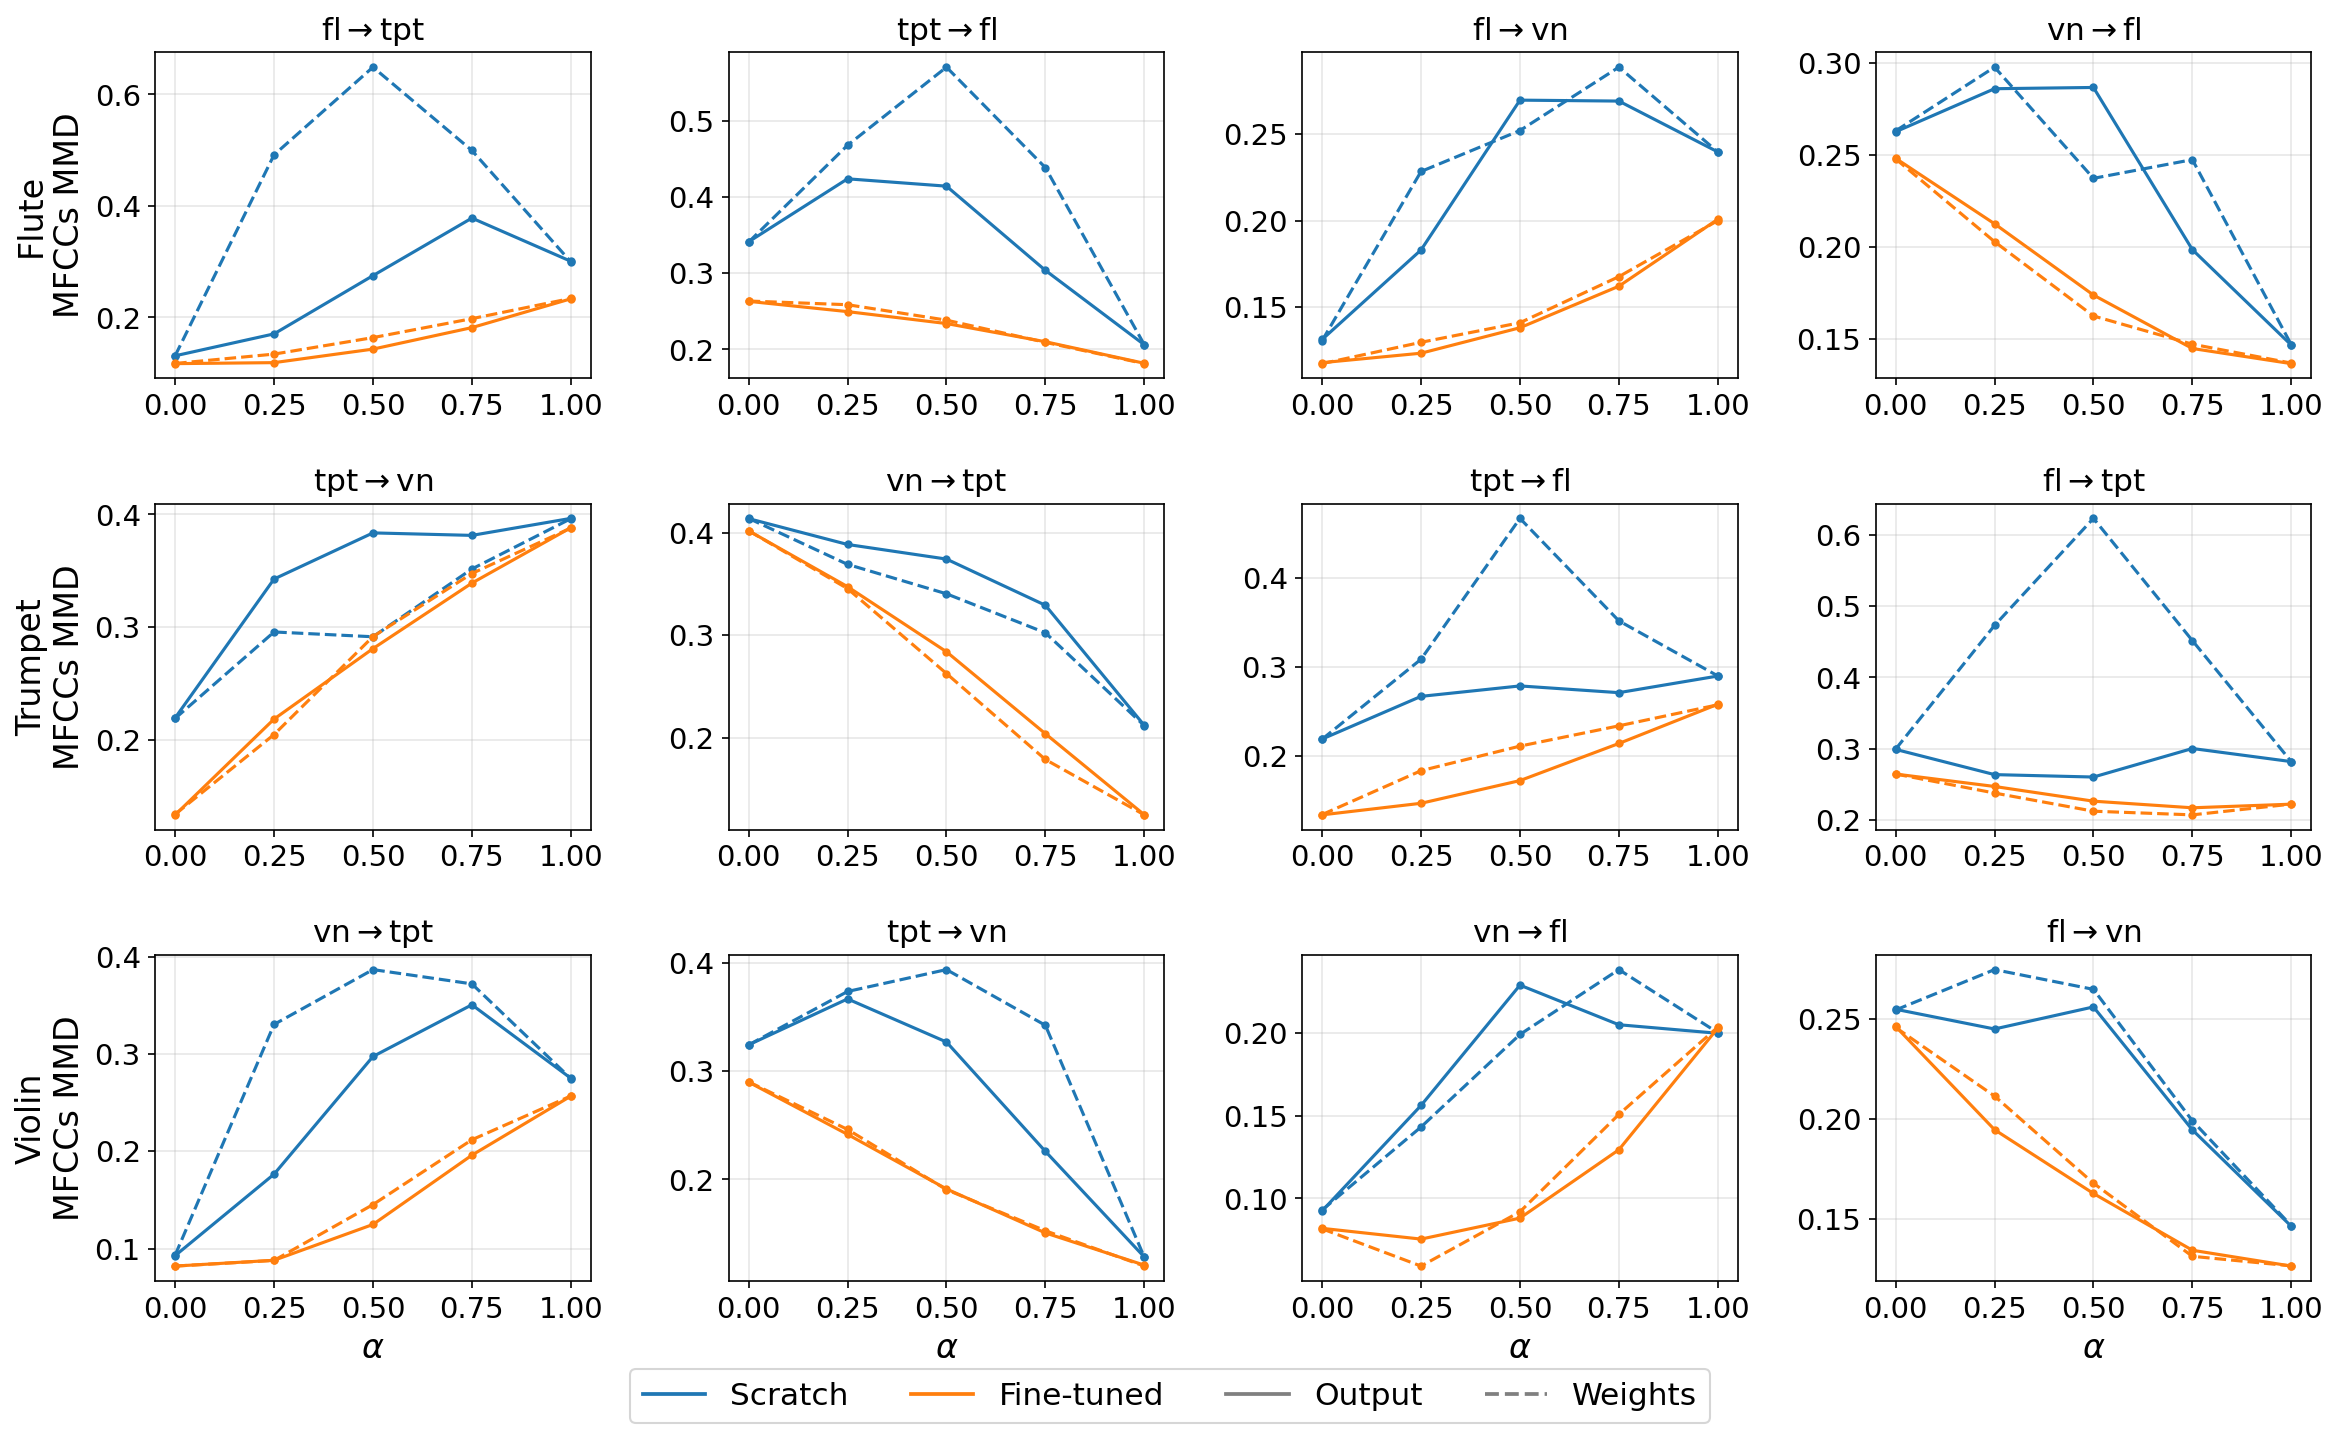

In [17]:
instruments = all_data["instrument"].dropna().unique()
pairs_by_ref = {
    instrument: all_data[all_data["instrument"] == instrument]["pair"].dropna().unique()
    for instrument in instruments
}
n_cols = max(len(pairs) for pairs in pairs_by_ref.values())

fig, axes = plt.subplots(
    len(instruments),
    n_cols,
    figsize=(4 * n_cols, 3.2 * len(instruments))
)

for i, instrument in enumerate(instruments):
    pairs_for_instrument = pairs_by_ref[instrument]

    for j in range(n_cols):
        ax = axes[i, j]
        if j >= len(pairs_for_instrument):
            ax.axis("off")
            continue

        pair = pairs_for_instrument[j]

        for model in ["from_scratch", "finetuned"]:
            for method in ["output", "weights"]:
                plot_subset(all_data, instrument, pair, method, model, ax)


        ax.set_title(str(pair).replace("_", r"$\to$"), fontsize=15)
        ax.grid(alpha=0.3)
        alpha_ticks = [0, 0.25, 0.5, 0.75, 1.0]
        ax.set_xticks(alpha_ticks)

        if i == len(instruments) - 1:
            ax.set_xlabel(r"$\alpha$")
        if j == 0:
            ax.set_ylabel(f"{instrument}\nMFCCs MMD")

legend_handles = [
    Line2D([0], [0], color="tab:blue", label="Scratch"),
    Line2D([0], [0], color="tab:orange", label="Fine-tuned"),
    Line2D([0], [0], color="gray", linestyle="-", label="Output"),
    Line2D([0], [0], color="gray", linestyle="--", label="Weights")
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=15
)

plt.tight_layout()
plt.show()

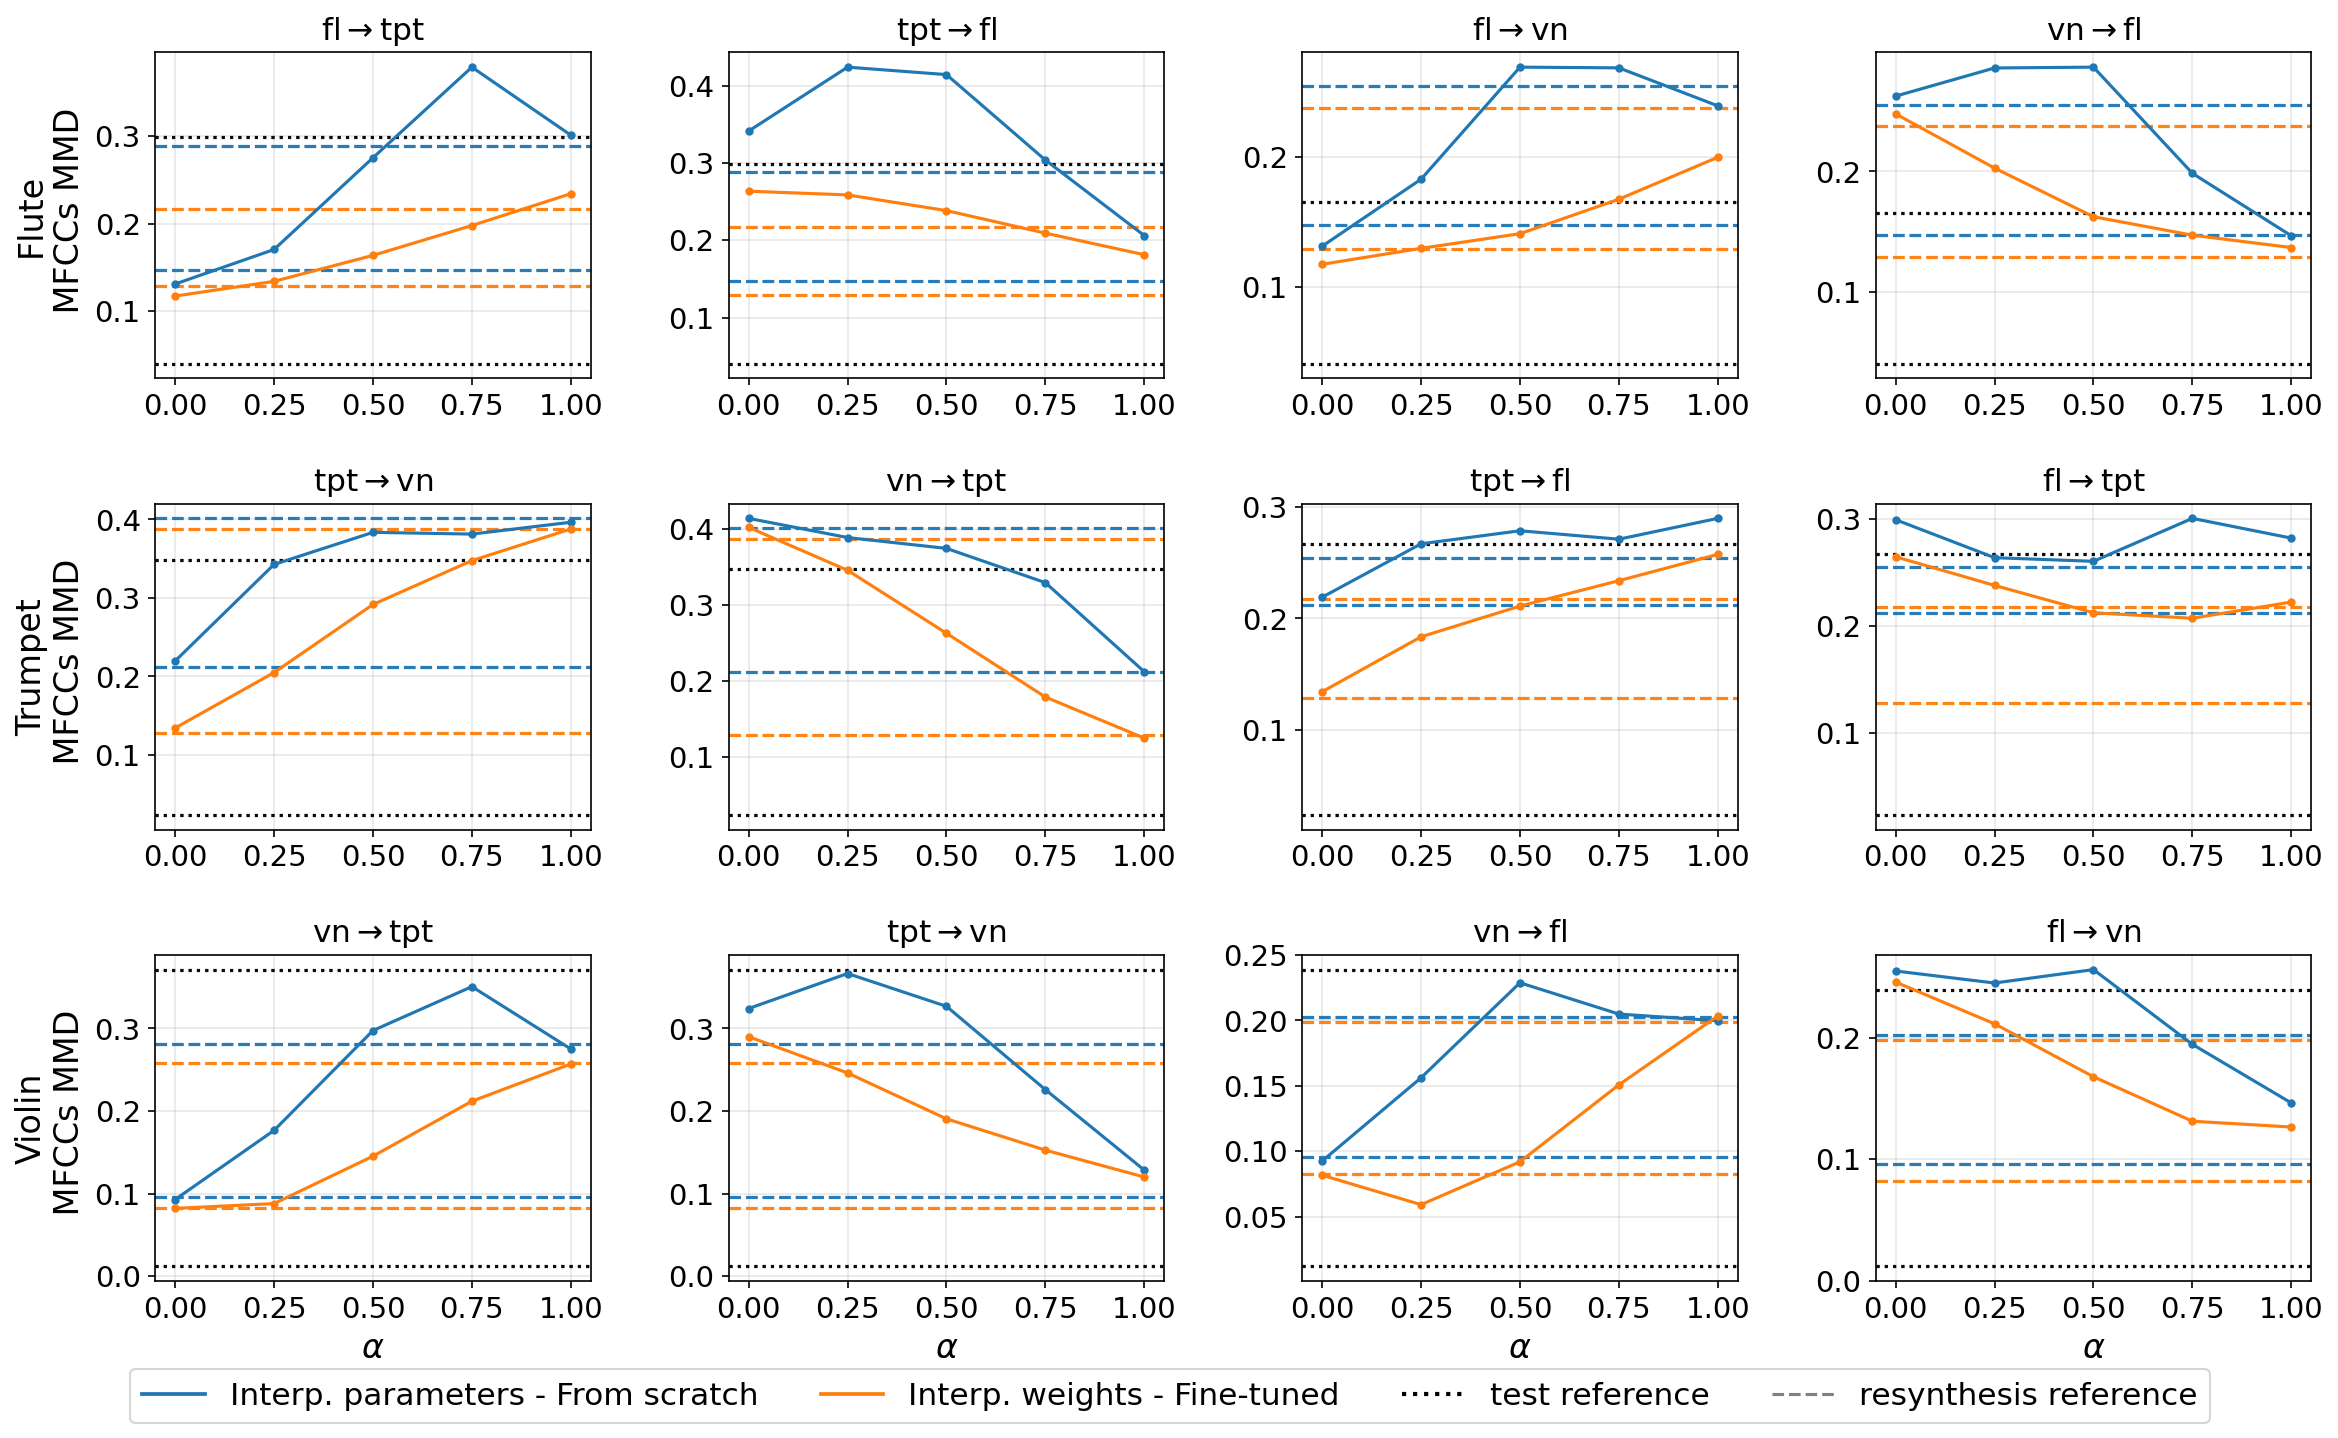

In [25]:
def plot_baselines(df, instrument, pair, ax, color):
    insts = normalize_pair_name(pair)

    for inst in insts:
        test_distance = df[
            (df["instrument"] == instrument)
            & (df["resynth_path"].astype(str).str.contains(f"test_{inst}", case=False, na=False))
        ]["distance"]

        if not test_distance.empty:
            ax.axhline(
                y=float(test_distance.iloc[0]),
                linestyle=":",
                linewidth=1.5,
                color=color,
                alpha=0.8,
            )
        
        for model in ["from_scratch", "finetuned"]:
            model_resynth_distance = df[
                (df["instrument"] == instrument) &
                (df["model"] == model) &
                (df["resynth_path"].astype(str).str.split("/").str[-1] == inst)
            ]["distance"]

            if not model_resynth_distance.empty:
                ax.axhline(
                    y=float(model_resynth_distance.iloc[0]),
                    linestyle="--",
                    linewidth=1.5,
                    color=model_colors[model],
                    alpha=0.8,
                    label=f"{model} resynthesis"
                )

model_colors = {"from_scratch": "tab:blue", "finetuned": "tab:orange"}
method_styles = {"output": "-", "weights": "-"}

instruments = all_data["instrument"].dropna().unique()
pairs_by_ref = {
    instrument: all_data[all_data["instrument"] == instrument]["pair"].dropna().unique()
    for instrument in instruments
}
n_cols = max(len(pairs) for pairs in pairs_by_ref.values())

fig, axes = plt.subplots(
    len(instruments),
    n_cols,
    figsize=(4 * n_cols, 3.2 * len(instruments))
)

for i, instrument in enumerate(instruments):
    pairs_for_instrument = pairs_by_ref[instrument]

    for j in range(n_cols):
        ax = axes[i, j]
        if j >= len(pairs_for_instrument):
            ax.axis("off")
            continue

        pair = pairs_for_instrument[j]

        for model in ["from_scratch", "finetuned"]:
            plot_baselines(all_data, instrument, pair, ax, "black")

        for model, method in [("from_scratch", "output"), ("finetuned", "weights")]:
            plot_subset(all_data, instrument, pair, method, model, ax)

        ax.set_title(str(pair).replace("_", r"$\to$"), fontsize=15)
        ax.grid(alpha=0.3)
        alpha_ticks = [0, 0.25, 0.5, 0.75, 1.0]
        ax.set_xticks(alpha_ticks)

        if i == len(instruments) - 1:
            ax.set_xlabel(r"$\alpha$")
        if j == 0:
            ax.set_ylabel(f"{instrument}\n MFCCs MMD")

legend_handles = [
    Line2D([0], [0], color="tab:blue", label="Interp. parameters - From scratch"),
    Line2D([0], [0], color="tab:orange", label="Interp. weights - Fine-tuned"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=2, label="test reference"),
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1.5, label="resynthesis reference"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=15
)

plt.tight_layout()
plt.show()

In [243]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

INSTRUMENT_ALIASES = {
    "fl": "Flute",
    "flute": "Flute",
    "vn": "Violin",
    "violin": "Violin",
    "vln": "Violin",
    "tpt": "Trumpet",
    "trumpet": "Trumpet",
    "tp": "Trumpet",
}

model_colors = {"from_scratch": "tab:blue", "finetuned": "tab:orange"}
method_styles = {"output": "-", "weights": "--"}

def normalize_instrument_name(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    return INSTRUMENT_ALIASES.get(s, s.title())

def reformat_alpha(df):
    df = df.copy()
    df["alpha"] = (
        df["alpha"]
        .astype(str)
        .str.replace("alpha_", "", regex=False)
        .astype(float)
    )
    return df

all_data = reformat_alpha(data_all)

def normalize_pair_name(pair):
    if pd.isna(pair):
        return []
    s = str(pair).lower()
    s = s.replace("->", "_").replace("-", "_").replace("/", "_")
    s = s.replace(" to ", "_")
    parts = re.split(r"[_\s]+", s)
    out = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        norm = INSTRUMENT_ALIASES.get(p, p.title())
        if norm.lower() not in {"baseline", "resynthesis", "test"}:
            out.append(norm)
    return out

def pair_is_between(pair, allowed_instruments):
    names = set(normalize_pair_name(pair))
    return len(names) >= 2 and names.issubset(set(allowed_instruments))


def plot_subset(df, instrument, pair, method, model, ax):
    subset = df[
        (df["instrument"] == instrument)
        & (df["pair"] == pair)
        & (df["method"] == method)
        & (df["model"] == model)
    ].sort_values("alpha")

    if subset.empty:
        return

    ax.plot(
        subset["alpha"],
        subset["distance"],
        marker="o",
        markersize=3,
        linestyle=method_styles[method],
        color=model_colors[model],
        linewidth=1.5,
    )

def plot_resynth_reference(df, instrument, pair, ax, color):
    insts = normalize_pair_name(pair)

    for inst in insts:
        vals = df[
            (df["instrument"] == instrument)
            & (df["pair"] == "resynthesis")
        ]["distance"]

        if not vals.empty:
            ax.axhline(
                y=float(vals.iloc[0]),
                linestyle="--",
                linewidth=1.2,
                color=color,
                alpha=0.8,
            )

def plot_baseline(df, instrument, ax):
    vals = df[
        (df["instrument"] == instrument) & (df["resynth_path"].astype(str).str.contains(f"test_{instrument}", case=False, na=False))
    ]["distance"]

    if not vals.empty:
        ax.axhline(
            y=float(vals.iloc[0]),
            linestyle=":",
            linewidth=1.2,
            color="gray",
        )


def plot_pair(allowed_instruments, all_data):
    all_data = all_data[all_data["instrument"].isin(allowed_instruments)].copy()

    valid_pairs = {
        instrument: [
            p for p in all_data[all_data["instrument"] == instrument]["pair"].dropna().unique()
            if p != "baseline_test" and pair_is_between(p, allowed_instruments)
        ]
        for instrument in allowed_instruments
    }

    print("valid_pairs:", valid_pairs)

    # guard against empty plot grid
    n_cols = max((len(v) for v in valid_pairs.values()), default=1)
    if n_cols == 0:
        n_cols = 1

    fig, axes = plt.subplots(
        len(allowed_instruments),
        n_cols,
        figsize=(4 * n_cols, 3.2 * len(allowed_instruments))
    )

    for i, instrument in enumerate(allowed_instruments):
        pairs_for_instrument = valid_pairs[instrument]

        for j in range(n_cols):
            ax = axes[i, j]

            if j >= len(pairs_for_instrument):
                ax.axis("off")
                continue

            pair = pairs_for_instrument[j]

            for model in ["from_scratch", "finetuned"]:
                for method in ["output", "weights"]:
                    plot_subset(all_data, instrument, pair, method, model, ax)

            for model in ["from_scratch", "finetuned"]:
                plot_reference(all_data, instrument, pair, ax, model_colors[model])

            plot_baseline(all_data, instrument, ax)

            ax.set_title(str(pair).replace("_", r"$\to$"), fontsize=10)
            ax.grid(alpha=0.3)
            alpha_ticks = [0, 0.25, 0.5, 0.75, 1.0]
            ax.set_xticks(alpha_ticks)

            if i == len(allowed_instruments) - 1:
                ax.set_xlabel(r"$\alpha$")
            if j == 0:
                ax.set_ylabel(f"{instrument}\nMMD")

    legend_handles = [
        Line2D([0], [0], color="tab:blue", label="Model trained from scratch"),
        Line2D([0], [0], color="tab:orange", label="Fine-tuned model"),
        Line2D([0], [0], color="gray", linestyle="-", label="Output"),
        Line2D([0], [0], color="gray", linestyle="--", label="Weights")
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=6,
        bbox_to_anchor=(0.5, -0.05)
    )

    plt.tight_layout()
    plt.show()

valid_pairs: {'Violin': ['vn_fl', 'fl_vn'], 'Flute': ['fl_vn', 'vn_fl']}


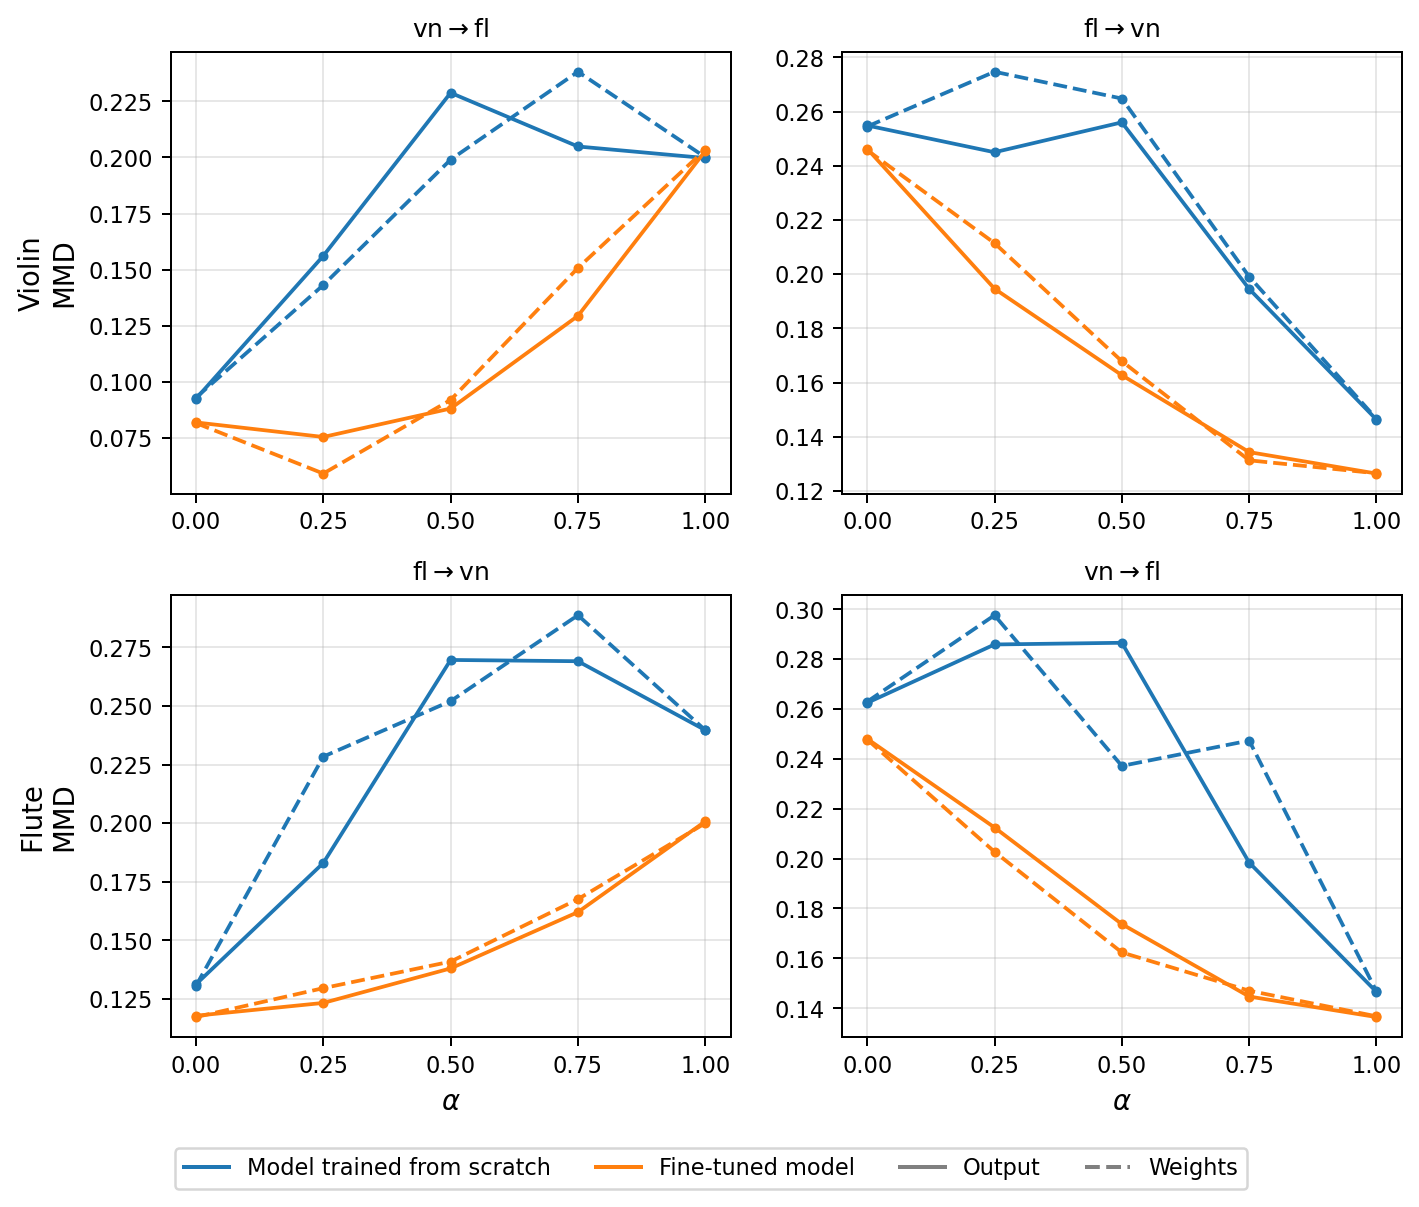

In [244]:
plot_pair(["Violin", "Flute"], all_data)

valid_pairs: {'Violin': ['vn_tpt', 'tpt_vn'], 'Trumpet': ['tpt_vn', 'vn_tpt']}


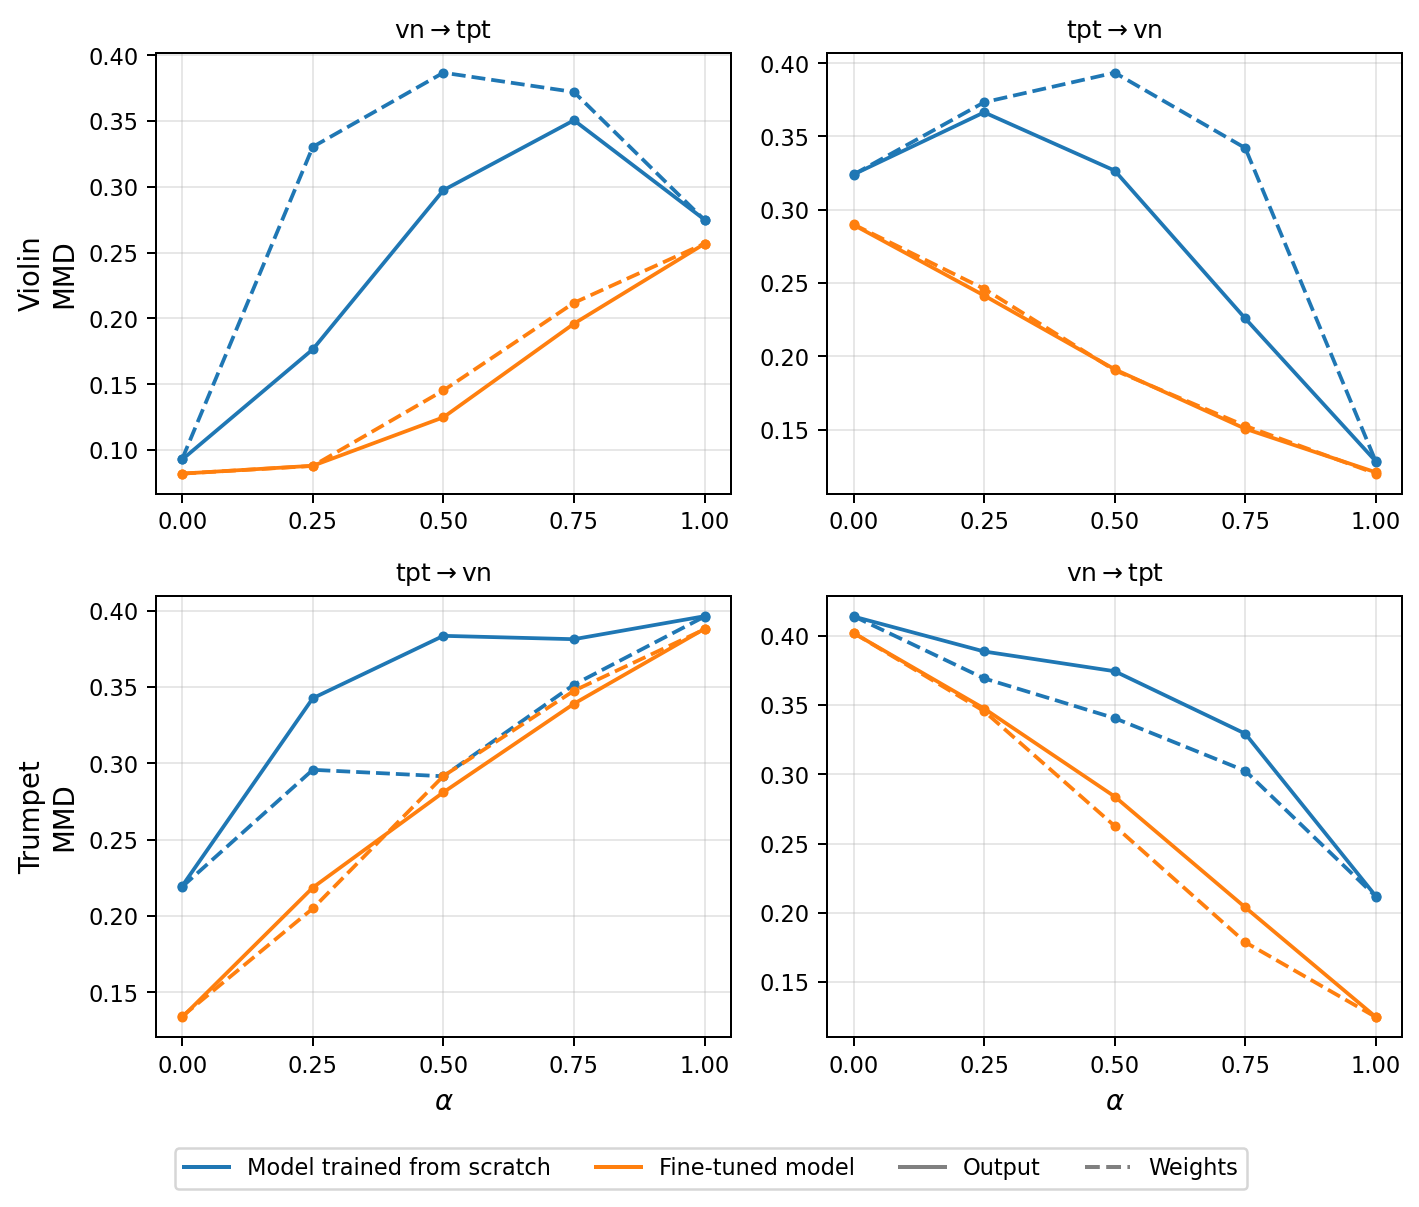

In [245]:
plot_pair(["Violin", "Trumpet"], all_data)

valid_pairs: {'Flute': ['fl_tpt', 'tpt_fl'], 'Trumpet': ['tpt_fl', 'fl_tpt']}


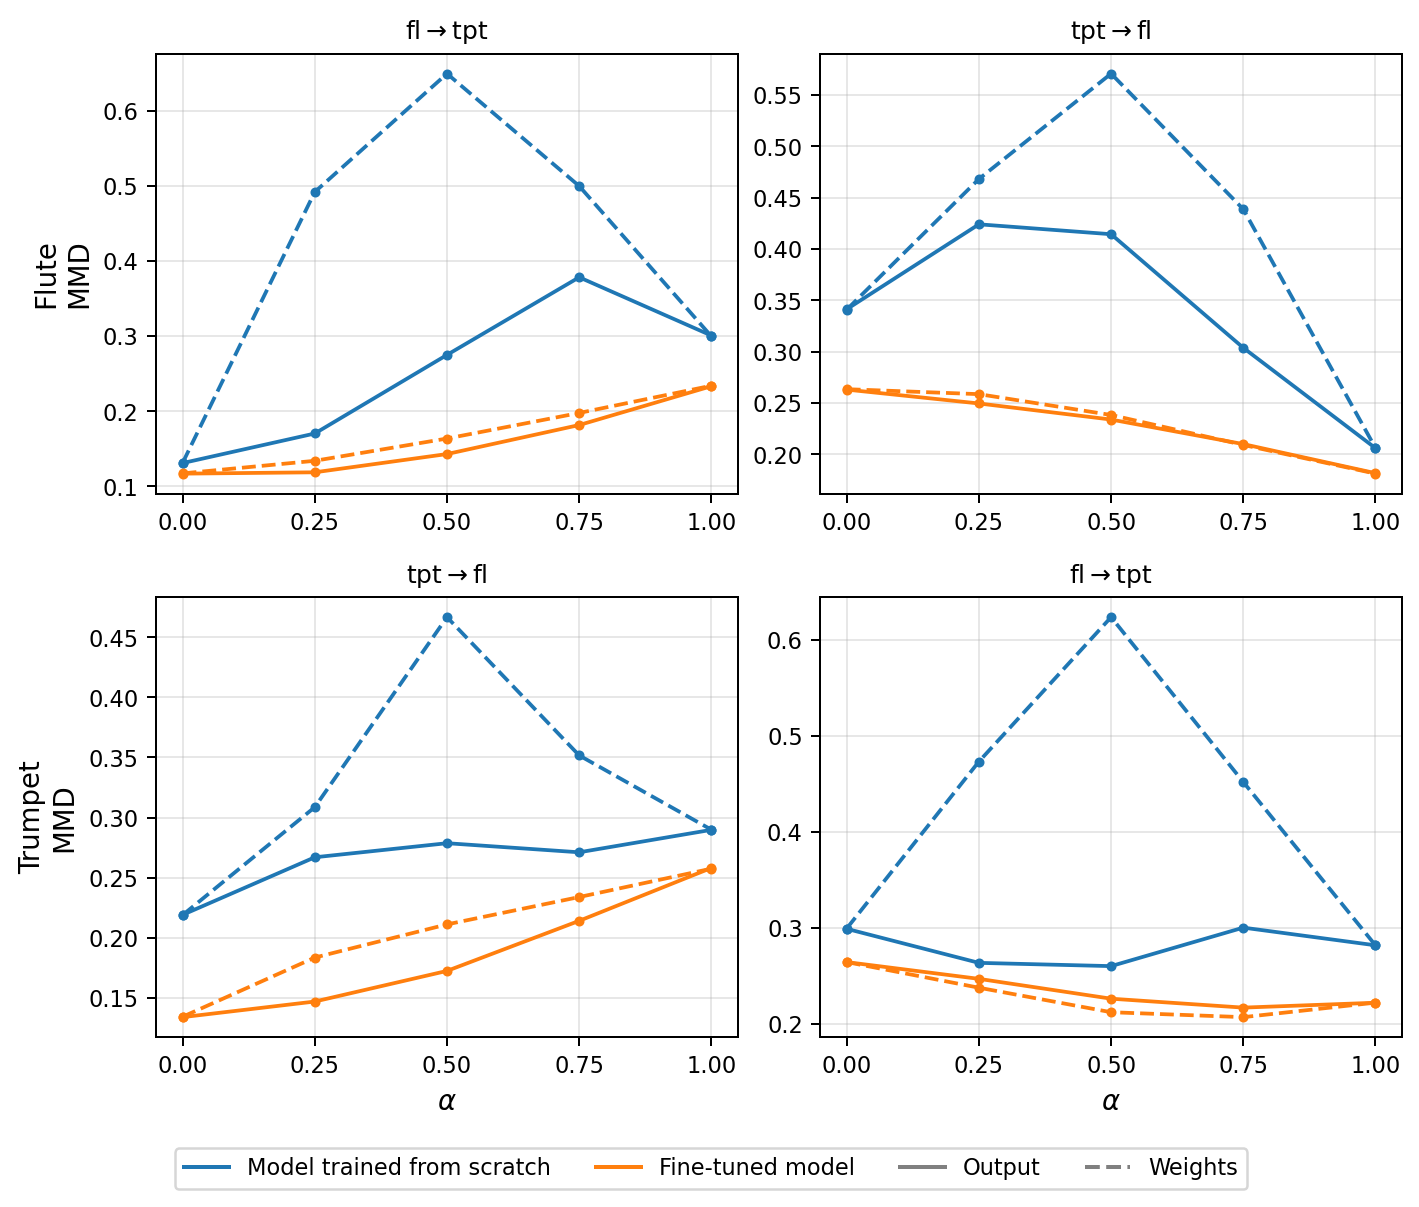

In [246]:
plot_pair(["Flute", "Trumpet"], all_data)